# vrs-matcher — Example Cohort

This notebook walks through the full vrs-matcher workflow on a small example cohort (example-cohort.vcf):

The example VCF contains three samples (`SAMPLE_A`, `SAMPLE_B`, `SAMPLE_C`) at
three biallelic sites, each pre-annotated with [GA4GH VRS](https://www.ga4gh.org/product/variation-representation/) allele identifiers.

## 1 · Install

In [1]:
# vrs-matcher is installed directly from the GitHub repository.
%pip install --quiet git+https://github.com/EllrottLab/vrs-matcher.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.7 MB/s eta 0:00:00


## 2 · Download the example VCF

In [ ]:
import urllib.request
from pathlib import Path

# Pinned to a specific commit so the notebook stays reproducible.
# Update the SHA when you want to pull a newer version of the example files.
BASE = "https://raw.githubusercontent.com/EllrottLab/vrs-matcher/8a620f6/examples"
FILES = [
    "example-cohort.vcf.gz",
    "example-cohort.vcf.gz.tbi",
]

for fname in FILES:
    dest = Path(fname)
    if not dest.exists():
        urllib.request.urlretrieve(f"{BASE}/{fname}", dest)
    print(f"✓ {dest}  ({dest.stat().st_size:,} bytes)")

VCF_PATH = "example-cohort.vcf.gz"

✓ example-cohort.vcf.gz  (429 bytes)
✓ example-cohort.vcf.gz.tbi  (106 bytes)


### Peek at the VCF header and records

In [4]:
import cyvcf2

vcf = cyvcf2.VCF(VCF_PATH)
print("Samples:", vcf.samples)
print()
for rec in vcf:
    vrs = rec.INFO.get("VRS_Allele_IDs", "—")
    print(f"{rec.CHROM}:{rec.POS}  REF={rec.REF}  ALT={rec.ALT}  VRS={vrs}")
vcf.close()

Samples: ['SAMPLE_A', 'SAMPLE_B', 'SAMPLE_C']

chr1:100  REF=A  ALT=['T']  VRS=ga4gh:VA.abc123
chr1:200  REF=G  ALT=['C']  VRS=ga4gh:VA.def456
chr1:300  REF=T  ALT=['A']  VRS=ga4gh:VA.ghi789


## 3 · Load samples into the index

### Python API

In [5]:
from vrs_matcher.loader import load_samples

DB_PATH = "cohort.db"

n = load_samples(VCF_PATH, DB_PATH)
print(f"Loaded {n} allele record(s) into {DB_PATH}")

Loaded 6 allele record(s) into cohort.db


### CLI equivalent

In [6]:
!vrs-matcher load-samples example-cohort.vcf.gz --db cohort.db

Loaded 6 allele records into cohort.db


## 4 · Inspect the index

In [8]:
from vrs_matcher.db import open_db

conn = open_db(DB_PATH)

print("=== Registered samples ===")
for row in conn.execute("SELECT sample_id FROM samples ORDER BY sample_id"):
    print(" ", row["sample_id"])

print()
print("=== Allele index (sample_allele) ===")
header = f"{'sample_id':<12} {'vrs_id':<28} {'gt':<6} {'zygosity':<10} {'chrom':<6} {'pos'}"
print(header)
print("-" * len(header))
for row in conn.execute(
    "SELECT sample_id, vrs_id, gt, zygosity, chrom, pos"
    " FROM sample_allele ORDER BY chrom, pos, sample_id"
):
    sid = row["sample_id"]
    vid = row["vrs_id"]
    gt = row["gt"]
    zyg = row["zygosity"]
    chrom = row["chrom"]
    pos = row["pos"]
    print(f"{sid:<12} {vid:<28} {gt:<6} {zyg:<10} {chrom:<6} {pos}")

conn.close()

=== Registered samples ===
  SAMPLE_A
  SAMPLE_B
  SAMPLE_C

=== Allele index (sample_allele) ===
sample_id    vrs_id                       gt     zygosity   chrom  pos
----------------------------------------------------------------------
SAMPLE_A     ga4gh:VA.abc123              0/1    HET        chr1   100
SAMPLE_B     ga4gh:VA.abc123              0/1    HET        chr1   100
SAMPLE_A     ga4gh:VA.def456              1/1    HOM_ALT    chr1   200
SAMPLE_C     ga4gh:VA.def456              0/1    HET        chr1   200
SAMPLE_A     ga4gh:VA.ghi789              0/1    HET        chr1   300
SAMPLE_B     ga4gh:VA.ghi789              0/1    HET        chr1   300


## 5 · Match a pair of samples

### Python API

In [9]:
from vrs_matcher.db import open_db
from vrs_matcher.matcher import match_pair

conn = open_db(DB_PATH)

result = match_pair(conn, "SAMPLE_A", "SAMPLE_B")

print("SAMPLE_A  vs  SAMPLE_B")
print(f"  Jaccard similarity:   {result.jaccard:.4f}")
print(f"  Weighted concordance: {result.weighted_concordance:.4f}")
print(f"  Shared VRS IDs:       {len(result.shared_vrs_ids)}")
print(f"  Total alleles (A/B):  {result.total_a} / {result.total_b}")
if result.shared_vrs_ids:
    print("  Shared IDs:")
    for vid in sorted(result.shared_vrs_ids):
        print(f"    {vid}")

conn.close()

SAMPLE_A  vs  SAMPLE_B
  Jaccard similarity:   0.6667
  Weighted concordance: 1.0000
  Shared VRS IDs:       2
  Total alleles (A/B):  3 / 2
  Shared IDs:
    ga4gh:VA.abc123
    ga4gh:VA.ghi789


### CLI equivalent

In [10]:
!vrs-matcher match-samples SAMPLE_A SAMPLE_B --db cohort.db

Jaccard:              0.6667
Weighted concordance: 1.0000
Shared variants:      2
Total alleles (A/B):  3 / 2


## 6 · Rank SAMPLE_A against all others

### Python API

In [11]:
from vrs_matcher.matcher import match_against_all

conn = open_db(DB_PATH)
results = match_against_all(conn, "SAMPLE_A")
conn.close()

print(f"{'Rank':<5} {'Sample':<12} {'Jaccard':>8} {'WConc':>8} {'Shared':>8}")
print("-" * 46)
for i, r in enumerate(results, 1):
    other = r.sample_b if r.sample_a == "SAMPLE_A" else r.sample_a
    shared = len(r.shared_vrs_ids)
    print(f"{i:<5} {other:<12} {r.jaccard:>8.4f} {r.weighted_concordance:>8.4f} {shared:>8}")

Rank  Sample        Jaccard    WConc   Shared
----------------------------------------------
1     SAMPLE_B       0.6667   1.0000        2
2     SAMPLE_C       0.3333   0.5000        1


### CLI equivalent

In [12]:
!vrs-matcher match-sample SAMPLE_A --db cohort.db

Sample                          Jaccard    WConc   Shared
------------------------------------------------------------
SAMPLE_B                         0.6667   1.0000        2
SAMPLE_C                         0.3333   0.5000        1


## 7 · Pairwise similarity heatmap

In [13]:
%pip install --quiet cyvcf2 matplotlib numpy

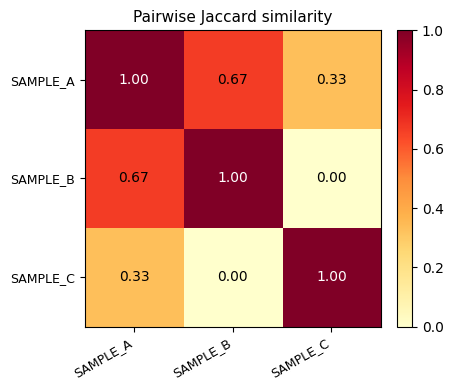

In [14]:
import itertools

import matplotlib.pyplot as plt
import numpy as np

from vrs_matcher.db import list_samples

conn = open_db(DB_PATH)

samples = sorted(list_samples(conn))
n = len(samples)
idx = {s: i for i, s in enumerate(samples)}

matrix = np.eye(n)
for a, b in itertools.combinations(samples, 2):
    r = match_pair(conn, a, b)
    matrix[idx[a], idx[b]] = r.jaccard
    matrix[idx[b], idx[a]] = r.jaccard

conn.close()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matrix, vmin=0, vmax=1, cmap="YlOrRd")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(samples, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(samples, fontsize=9)
ax.set_title("Pairwise Jaccard similarity", fontsize=11)

for i in range(n):
    for j in range(n):
        color = "white" if matrix[i, j] >= 0.7 else "black"
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=10, color=color)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()